In [96]:
# Import initial libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [97]:
# Load obesity data set
df = pd.read_csv("ObesityDataSet.csv")

In [98]:
# Size of data set
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
# First five rows of data set
df.head()

Rows: 2111, Columns: 17


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [99]:
# Rename column for simplicity
df = df.rename(columns={'family_history_with_overweight':'fam_hist'})

In [100]:
# Create dictionaries to remap categorical features
gender_dict = {'Female' :0, 'Male' : 1}
yn_dict = {'no' :0, 'yes' : 1}
ynm_dict = {'no' :0, 'Sometimes' : 1, 'Frequently' : 2, 'Always' : 3}
weight_dict = {'Insufficient_Weight' : 1, 'Normal_Weight' : 2, 'Overweight_Level_I' : 3, 'Overweight_Level_II' :4, \
               'Obesity_Type_I' : 5, 'Obesity_Type_II' : 6, 'Obesity_Type_III' : 7}
# Dictionary to remap values to shortened titles
transit_dict = {'Public_Transportation': 'Public', 'Automobile': 'Car'}

In [101]:
# Remap dataframe with previously established dictionaries
df = df.replace({'Gender': gender_dict,'fam_hist': yn_dict,'FAVC': yn_dict, 'CAEC': ynm_dict, \
                'MTRANS': transit_dict, 'SMOKE': yn_dict, 'SCC': yn_dict, 'CALC': ynm_dict, 'NObeyesdad': weight_dict})

In [102]:
# First five rows with after data and columns renamed and/or remapped 
df.head()

,Gender,Age,Height,Weight,fam_hist,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,Public,2
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,Public,2
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,Public,2
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,Walking,3
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,Public,4


In [103]:
# Create features set by creating dummy variables for the main source of transportation 
# Also dropping the target column 
features = pd.get_dummies(df.drop(['NObeyesdad'], axis=1))

In [104]:
# Creating a correlation matrix to ensure none of the intended features do not have high corrlelation
corr_mx = features.corr()

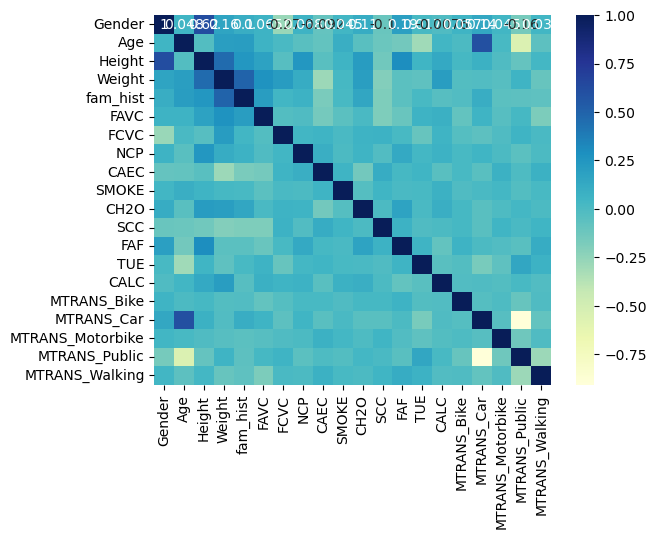

In [105]:
# Correlation heatmap
sb.heatmap(features.corr(), cmap="YlGnBu", annot=True)
plt.show()

In [106]:
# Create target variable
target = df['NObeyesdad']

In [107]:
# Load additional libraries for model and model assessment
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [108]:
# Split data into training and test set (80/20)
feat_train, feat_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=0)

In [109]:
# Create a pipeline with a min, max scaler using 0-1 and Random Forest Classifier
min_max = preprocessing.MinMaxScaler(feature_range=(0,1))
rf = RandomForestClassifier(random_state=0, n_jobs=-1)
pipe = Pipeline([('min-max', min_max), ('rf', rf)])

In [110]:
# Fitting pipeline with the training data
pipe.fit(feat_train, target_train)

Pipeline(steps=[('min-max', MinMaxScaler()),
                ('rf', RandomForestClassifier(n_jobs=-1, random_state=0))])

In [111]:
# Creating predictions from the Random Forest model
pred = pipe.predict(feat_test)

In [112]:
# Accuracy of model with predicitons and actuals for the test data
acc = accuracy_score(target_test, pred)
print(f"Random Forest Accuracy: {(acc*100):0.3}%")

Random Forest Accuracy: 94.6%


In [113]:
# Classification report
print(classification_report(target_test, pred))

              precision    recall  f1-score   support

           1       1.00      0.89      0.94        65
           2       0.74      1.00      0.85        57
           3       0.98      0.84      0.91        57
           4       0.96      0.89      0.92        55
           5       1.00      0.99      0.99        67
           6       1.00      1.00      1.00        53
           7       1.00      1.00      1.00        69

    accuracy                           0.95       423
   macro avg       0.95      0.94      0.95       423
weighted avg       0.96      0.95      0.95       423



In [114]:
# create pipeline with scaler and KNN model (k = 3)
from sklearn.neighbors import KNeighborsClassifier
knn_3 = KNeighborsClassifier(n_neighbors=3)
pipe_knn_3 = Pipeline([('min-max', min_max), ('knn', knn_3)])

In [115]:
# fit and test KNN model
pipe_knn_3.fit(feat_train, target_train)
pred_knn_3 = pipe_knn_3.predict(feat_test)
# accuracy score
acc_knn_3 = accuracy_score(target_test, pred_knn_3)
print(f"K-Nearest Neighbors (k = 3) Accuracy: {(acc_knn_3*100):0.3}%")
# model metrics report
print(classification_report(target_test, pred_knn_3))

K-Nearest Neighbors (k = 3) Accuracy: 77.8%
              precision    recall  f1-score   support

           1       0.73      0.88      0.80        65
           2       0.57      0.44      0.50        57
           3       0.63      0.70      0.67        57
           4       0.72      0.69      0.70        55
           5       0.84      0.73      0.78        67
           6       0.89      0.96      0.93        53
           7       0.99      1.00      0.99        69

    accuracy                           0.78       423
   macro avg       0.77      0.77      0.77       423
weighted avg       0.77      0.78      0.77       423



In [116]:
# create pipeline with scaler and KNN model (k = 5)
knn_5 = KNeighborsClassifier(n_neighbors=5)
pipe_knn_5 = Pipeline([('min-max', min_max), ('knn', knn_5)])
# fit and test KNN model
pipe_knn_5.fit(feat_train, target_train)
pred_knn_5 = pipe_knn_5.predict(feat_test)
# accuracy score
acc_knn_5 = accuracy_score(target_test, pred_knn_5)
print(f"K-Nearest Neighbors (k = 5) Accuracy: {(acc_knn_5*100):0.3}%")

K-Nearest Neighbors (k = 5) Accuracy: 75.2%


In [117]:
# Getting the importance of the feature as it impacts the model
feat_impt = pd.Series(rf.feature_importances_, index=feat_train.columns).sort_values(ascending=True)

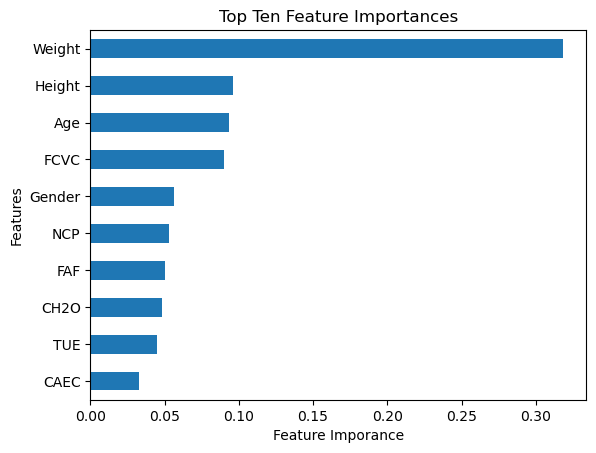

In [118]:
# Graph top ten important features
feat_impt.tail(10).plot.barh()
plt.xlabel('Feature Imporance')
plt.ylabel('Features')
plt.title('Top Ten Feature Importances')
plt.show()